# EDA Inicial — Dataset de Propiedades en Venta, Mérida, Yucatán

Análisis exploratorio del dataset recolectado manualmente en la Fase 1 
del proyecto. 60 propiedades en venta de 6 colonias de Mérida, Yucatán.
Fuente: Inmuebles24, mayo–junio 2026.

## 1. Configuración del entorno
Importación de librerías y configuración de parámetros globales de visualización.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Todo listo")

Matplotlib is building the font cache; this may take a moment.


Todo listo


## 2. Carga de datos

In [2]:
df = pd.read_csv('/Users/edson/Documents/GitHub/dataset-inmuebles-merida/data/propiedades.csv')
df.head()

,fecha_registro,url,url_archivo,operación,tipo_inmueble,colonia,precio,m2_construccion,m2_terreno,recamaras,banos,estacionamientos,antigüedad,es_preventa,notas
0,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,altabrisa,2390000,100,160,2,1,2.0,20.0,no,Casa en fraccionamiento Vista Alegre Norte. Ca...
1,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,departamento,altabrisa,2285000,46,46,1,1,1.0,NaN,si,"Preventa, múltiples unidades, precio cabecera ..."
2,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,departamento,altabrisa,6200000,160,160,2,3,2.0,NaN,no,"Country Towers Altabrisa, anuncio no especific..."
3,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,altabrisa,7500000,292,326,4,3,2.0,10.0,no,"Sin cuota de mantenimiento, piscina con cascad..."
4,2026-05-29,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,altabrisa,27000000,800,890,4,4,2.0,6.0,no,"Casa en condominio, piscina con baño completo,..."


## 3. Inspección inicial
Vista general del dataset: dimensiones, tipos de datos, primeras y últimas filas.

In [3]:
df.shape

(60, 15)

In [4]:
df.dtypes

fecha_registro          str
url                     str
url_archivo         float64
operación               str
tipo_inmueble           str
colonia                 str
precio                int64
m2_construccion       int64
m2_terreno            int64
recamaras             int64
banos                 int64
estacionamientos    float64
antigüedad          float64
es_preventa             str
notas                   str
dtype: object

In [5]:
df.tail()

,fecha_registro,url,url_archivo,operación,tipo_inmueble,colonia,precio,m2_construccion,m2_terreno,recamaras,banos,estacionamientos,antigüedad,es_preventa,notas
55,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,yucatan country club,38500000,900,1208,4,7,4.0,7.0,no,"piscina (8x3.5m), bodega, despacho con baño co..."
56,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,yucatan country club,41000000,730,752,4,4,3.0,NaN,no,"frente al campo de golf, family room, estudio ..."
57,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,departamento,yucatan country club,6200000,171,60,3,3,2.0,8.0,no,desarrollo Privada Serena (51 casas y 88 depar...
58,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,yucatan country club,12665000,496,525,3,3,2.0,7.0,no,"piscina con baño y asoleadero, jardín con casc..."
59,2026-06-07,https://www.inmuebles24.com/propiedades/clasif...,NaN,venta,casa,yucatan country club,12900000,410,466,3,4,2.0,NaN,no,piscina con veneciano y baño exterior (entrada...


## 4. Calidad de datos
Análisis de valores faltantes por columna y evaluación de su impacto en el análisis.

In [6]:
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df) * 100).round(1)
pd.DataFrame({'faltantes': faltantes, 'porcentaje': porcentaje})

,faltantes,porcentaje
fecha_registro,0,0.0
url,0,0.0
url_archivo,60,100.0
operación,0,0.0
tipo_inmueble,0,0.0
colonia,0,0.0
precio,0,0.0
m2_construccion,0,0.0
m2_terreno,0,0.0
recamaras,0,0.0


### Observaciones
- Las variables clave para el modelo (precio, m2_construccion, m2_terreno, recamaras, banos) 
  están completas al 100%.
- antigüedad tiene 65% de valores faltantes y tendrá uso limitado en fases posteriores.
- url_archivo está vacía por diseño: Inmuebles24 bloquea el archivado en Wayback Machine.
- estacionamientos tiene un solo valor faltante (1.7%), manejable.

## 5. Estadística descriptiva
Resumen estadístico de las variables numéricas: precio, m2, recámaras, baños, estacionamientos, antigüedad.

In [8]:
df[['precio', 'm2_construccion', 'm2_terreno', 'recamaras', 'banos', 'estacionamientos', 'antigüedad']].describe().round(2)

,precio,m2_construccion,m2_terreno,recamaras,banos,estacionamientos,antigüedad
count,60.00,60.00,60.00,60.00,60.00,59.00,21.00
mean,8163095.10,298.08,420.68,2.85,2.78,2.17,8.76
std,8761005.24,355.16,858.90,1.01,1.39,1.12,9.19
min,1790000.00,42.00,42.00,1.00,1.00,1.00,1.00
25%,2900000.00,126.00,126.50,2.00,2.00,1.00,3.00
50%,4942500.00,175.50,198.00,3.00,2.50,2.00,6.00
75%,8687500.00,356.25,423.75,3.25,3.00,2.00,10.00
max,41000000.00,2502.00,6531.00,5.00,7.00,6.00,40.00


### Observaciones
- precio y m2 presentan sesgo a la derecha (media >> mediana), 
  con outliers en el extremo superior. El modelo probablemente 
  requerirá transformación logarítmica del precio.
- recamaras es la variable más estable, centrada en 3.
- antigüedad solo cubre 21 de 60 registros; su uso en el modelo 
  será limitado.
- Se detectan posibles outliers en m2_construccion (max 2,502), 
  m2_terreno (max 6,531) y banos (max 7). Se investigarán en la 
  Sección 10.

## 6. Distribuciones univariadas
Distribución individual de cada variable numérica clave.

### 6.1 Precio

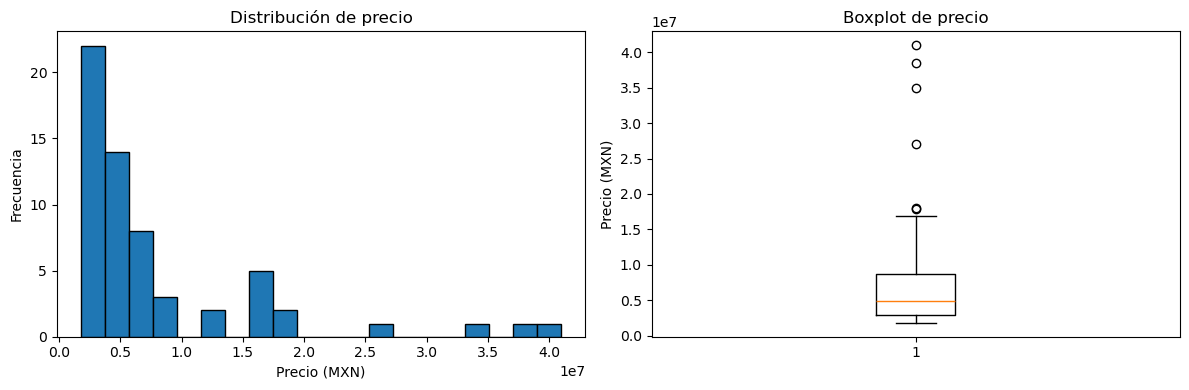

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['precio'], bins=20, edgecolor='black')
axes[0].set_title('Distribución de precio')
axes[0].set_xlabel('Precio (MXN)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['precio'])
axes[1].set_title('Boxplot de precio')
axes[1].set_ylabel('Precio (MXN)')

plt.tight_layout()
plt.show()

**Observación 6.1:** El precio muestra sesgo positivo marcado. La mayoría 
de propiedades se concentra entre \$2M y \$5M MXN, con una cola de 
propiedades de lujo que llegan hasta $41M. Se detectan 5 outliers en el 
extremo superior. Se confirma la necesidad de transformación logarítmica 
para el modelo.

### 6.2 Precio por m² de construcción

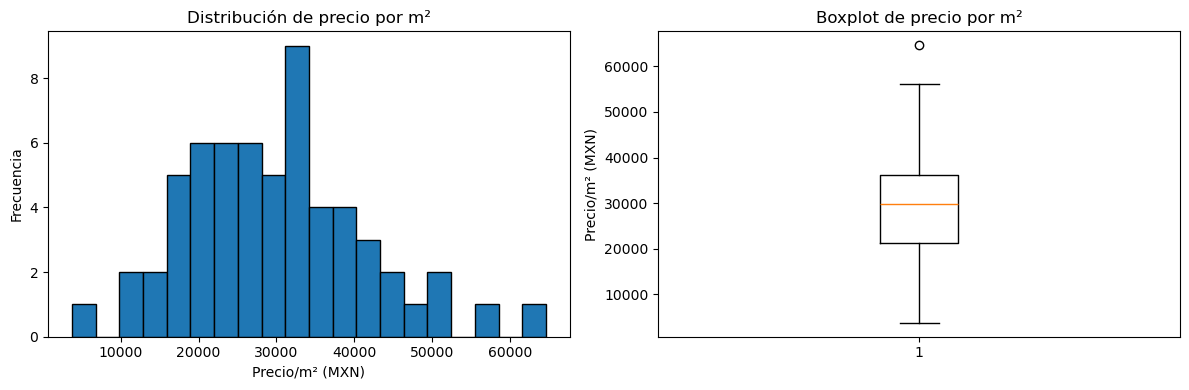

In [10]:
df['precio_m2'] = df['precio'] / df['m2_construccion']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['precio_m2'], bins=20, edgecolor='black')
axes[0].set_title('Distribución de precio por m²')
axes[0].set_xlabel('Precio/m² (MXN)')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['precio_m2'])
axes[1].set_title('Boxplot de precio por m²')
axes[1].set_ylabel('Precio/m² (MXN)')

plt.tight_layout()
plt.show()

**Observación 6.2:** El precio por m² de construcción muestra una 
distribución más simétrica que el precio absoluto, concentrada entre 
\$20,000 y \$35,000 MXN/m². Solo un outlier detectado (~\$65,000/m²). 
Esta métrica es más estable para comparar propiedades entre colonias.

### 6.3 Superficie de construcción

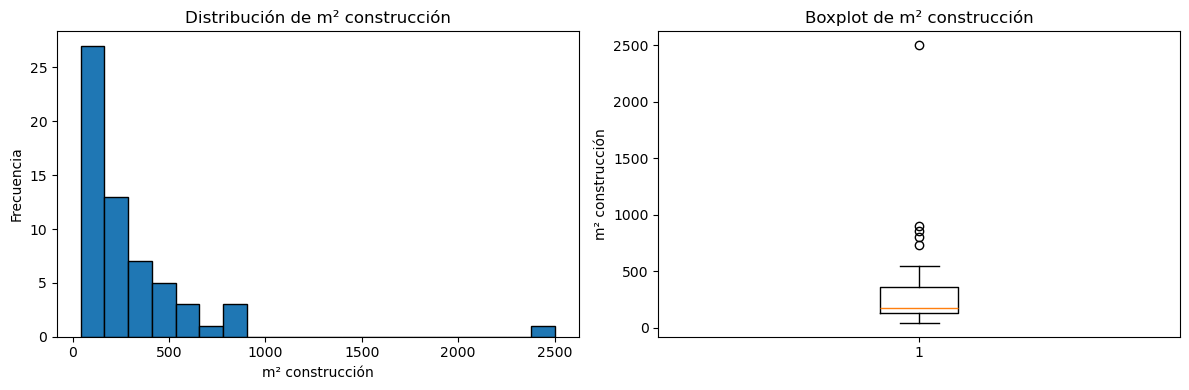

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['m2_construccion'], bins=20, edgecolor='black')
axes[0].set_title('Distribución de m² construcción')
axes[0].set_xlabel('m² construcción')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['m2_construccion'])
axes[1].set_title('Boxplot de m² construcción')
axes[1].set_ylabel('m² construcción')

plt.tight_layout()
plt.show()

**Observación 6.3:** m2_construccion presenta sesgo positivo fuerte, 
similar al precio. La mayoría de propiedades tiene entre 50 y 300 m². 
Se detecta un outlier extremo en ~2,500 m² que se investigará en la 
Sección 10.

### 6.4 Superficie de terreno

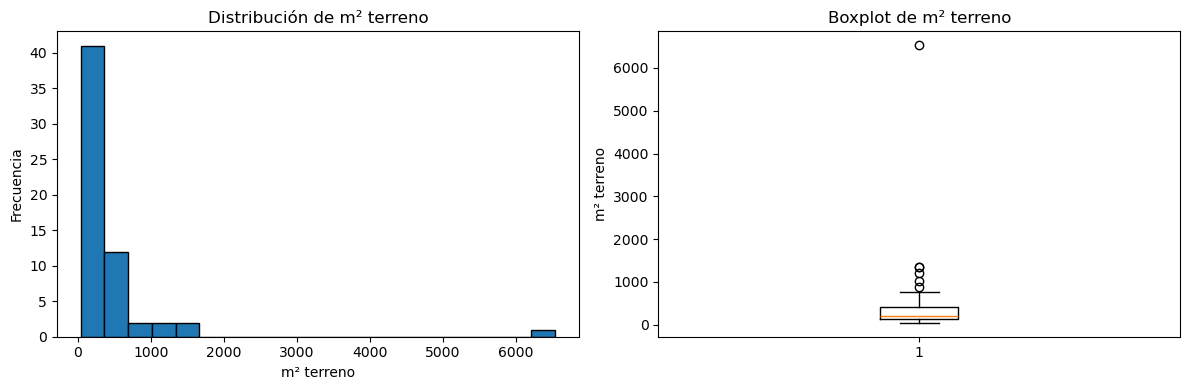

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['m2_terreno'], bins=20, edgecolor='black')
axes[0].set_title('Distribución de m² terreno')
axes[0].set_xlabel('m² terreno')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['m2_terreno'])
axes[1].set_title('Boxplot de m² terreno')
axes[1].set_ylabel('m² terreno')

plt.tight_layout()
plt.show()

**Observación 6.4:** m2_terreno presenta el sesgo positivo más pronunciado 
del dataset. La gran mayoría de propiedades tiene menos de 500 m² de 
terreno. Se detecta un outlier extremo en ~6,500 m² completamente aislado 
del resto, y varios outliers entre 1,000–1,300 m². Se investigarán en la 
Sección 10.

### 6.5 Recámaras

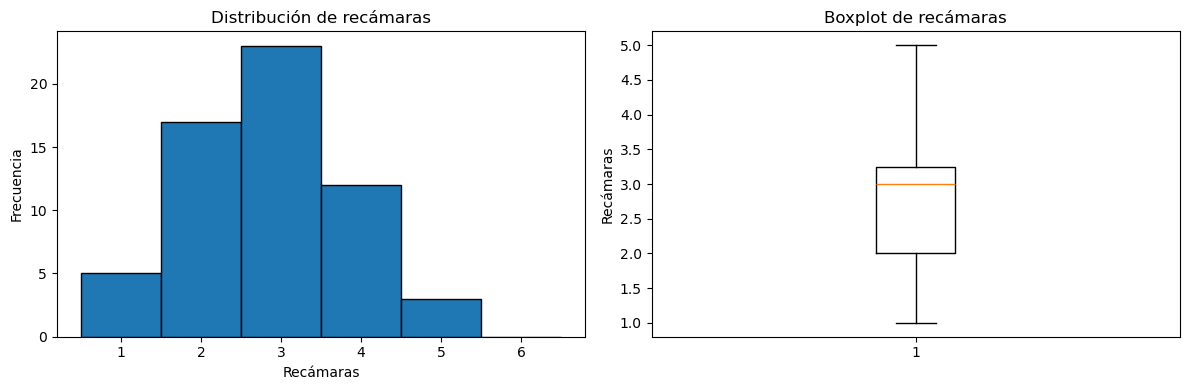

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['recamaras'], bins=range(1, 8), edgecolor='black', align='left')
axes[0].set_title('Distribución de recámaras')
axes[0].set_xlabel('Recámaras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(range(1, 7))

axes[1].boxplot(df['recamaras'])
axes[1].set_title('Boxplot de recámaras')
axes[1].set_ylabel('Recámaras')

plt.tight_layout()
plt.show()

**Observación 6.5:** Recámaras presenta la distribución más simétrica del 
dataset, centrada en 3. Rango de 1 a 5 sin outliers. Es la variable 
numérica más estable y será un predictor confiable en el modelo.

### 6.6 Baños

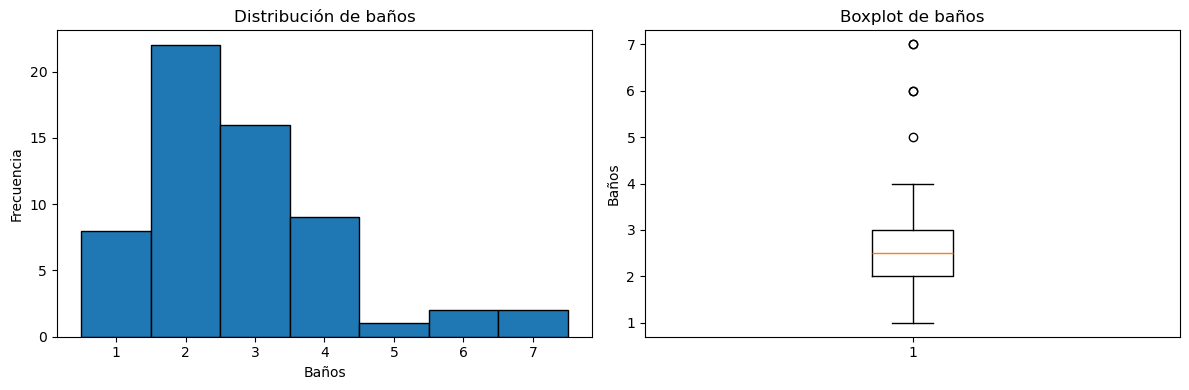

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['banos'], bins=range(1, 9), edgecolor='black', align='left')
axes[0].set_title('Distribución de baños')
axes[0].set_xlabel('Baños')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(range(1, 8))

axes[1].boxplot(df['banos'])
axes[1].set_title('Boxplot de baños')
axes[1].set_ylabel('Baños')

plt.tight_layout()
plt.show()

**Observación 6.6:** Baños muestra sesgo positivo moderado, centrado en 2. 
Se detectan 3 outliers en 5, 6 y 7 baños, probablemente propiedades de 
lujo. Recordar que medios baños no están capturados en esta columna sino 
en notas, por diseño del dataset.

### 6.7 Estacionamientos

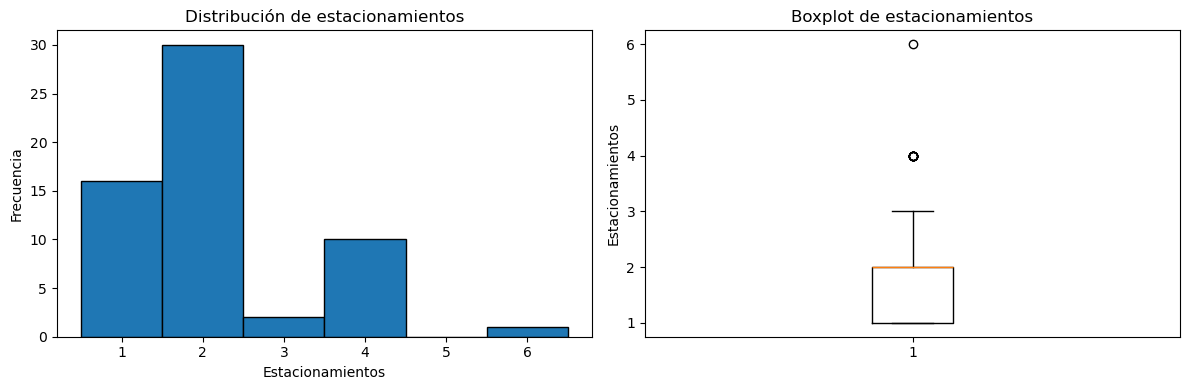

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['estacionamientos'].dropna(), bins=range(1, 8), edgecolor='black', align='left')
axes[0].set_title('Distribución de estacionamientos')
axes[0].set_xlabel('Estacionamientos')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xticks(range(1, 7))

axes[1].boxplot(df['estacionamientos'].dropna())
axes[1].set_title('Boxplot de estacionamientos')
axes[1].set_ylabel('Estacionamientos')

plt.tight_layout()
plt.show()

**Observación 6.7:** Estacionamientos se concentra en 1 y 2, con un segundo 
pico inesperado en 4 que sugiere un segmento de propiedades grandes con 
garage amplio, posiblemente de colonias premium. Outliers en 4 y 6 
estacionamientos. Un registro con valor faltante excluido del análisis.